# ATDL Tasks 5-12 — Artifact-First Advanced KD Continuation

This notebook resumes from the verified Task 1-4 state. It loads real Task 4, DKD, DIST, and the completed one-seed DIST continuation artifacts, verifies their provenance, generates comparisons and diagnostics, and records Tasks 5-12 that are not implemented in the production trainer as deferred. It never retrains completed work and never accesses the official CIFAR-10 test set.

**Verified starting point:** vanilla Task 4 = 95.12% +/- 0.15% validation; DKD = 94.88% three-seed mean; original DIST screen = 94.94%; continuation DIST ($T=1$, $\lambda=0.5$) = 95.02% one seed. The Task 4 control remains the final candidate.

## 0. Environment and immutable research contract

All cells below are artifact-first and validation-only. New training is disabled in this notebook because the only supported new continuation has already completed in `task7_dist_t1_lam05_r1`. The official test set remains locked.

In [1]:
from pathlib import Path
import json, os, hashlib
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = Path.cwd()
if ROOT.name != "ATDL-1":
    ROOT = Path("/home/vu-lab03-pc17/ATDL-1")
os.chdir(ROOT)
OUT = ROOT / "results" / "tasks5_12_continuation"
PLOTS = OUT / "plots"
OUT.mkdir(parents=True, exist_ok=True)
PLOTS.mkdir(parents=True, exist_ok=True)
TEST_FORBIDDEN = ("test_batch", "test_labels", "official_test", "cifar-10-batches-py/test")
def load_json(path):
    path = Path(path)
    if any(token in str(path).lower() for token in TEST_FORBIDDEN):
        raise RuntimeError(f"Official test firewall blocked: {path}")
    return json.loads(path.read_text())
STATE = load_json(ROOT / "research_state_checkpoint.json")
assert STATE["test_evaluation"] == "LOCKED_NOT_RUN"
assert STATE["active_training"] is None
print({"root": str(ROOT), "output": str(OUT), "test": STATE["test_evaluation"], "final": STATE["final_method"]})

{'root': '/home/vu-lab03-pc17/ATDL-1', 'output': '/home/vu-lab03-pc17/ATDL-1/results/tasks5_12_continuation', 'test': 'LOCKED_NOT_RUN', 'final': 'vanilla KD (Task 4 control)'}


## 1. Real Task 4 starting point and artifact registry

In [2]:
import csv
registry_paths = {
    "T2_FP32": ROOT / "results/task2_final_summary.json",
    "T3_ternary_noKD": ROOT / "results/task3_b2_default_summary.json",
    "T4_vanillaKD": ROOT / "results/task4/task4_b3_final_t2_lam09_aggregate_summary.json",
    "DKD": ROOT / "results/task4/task5_dkd_final_t2_lam09_a1_b8_r1_summary.json",
    "DIST_screen": ROOT / "results/task4/task6_dist_screen_t2_lam09_i1_a1_r1_summary.json",
    "DIST_continuation": ROOT / "results/task4/task7_dist_t1_lam05_r1_summary.json",
}
registry = {}
for name, path in registry_paths.items():
    assert path.exists(), f"Missing required preserved artifact: {path}"
    registry[name] = load_json(path)
    registry[name]["artifact_path"] = str(path.relative_to(ROOT))

rows = []
for name, data in registry.items():
    rows.append({
        "method": name,
        "validation_mean": data.get("validation_mean"),
        "validation_std": data.get("validation_std"),
        "validation_best": data.get("validation_best"),
        "best_seed": data.get("best_seed"),
        "test_evaluation": data.get("test_evaluation"),
        "status": "completed artifact" if name != "DIST_continuation" else "provisional one-seed artifact",
    })
print(json.dumps(rows, indent=2))
assert all(row["test_evaluation"] == "not_run" for row in rows)
with (OUT / "artifact_registry.csv").open("w", newline="") as handle:
    writer = csv.DictWriter(handle, fieldnames=rows[0].keys())
    writer.writeheader(); writer.writerows(rows)
print("Registered actual Task 4-family artifacts; no completed experiment will be retrained.")

[
  {
    "method": "T2_FP32",
    "validation_mean": 0.9533999999999999,
    "validation_std": 0.0014000000000000123,
    "validation_best": 0.9548,
    "best_seed": 43,
    "test_evaluation": "not_run",
    "status": "completed artifact"
  },
  {
    "method": "T3_ternary_noKD",
    "validation_mean": 0.9520666666666666,
    "validation_std": 0.0008082903768654466,
    "validation_best": 0.9528,
    "best_seed": 44,
    "test_evaluation": "not_run",
    "status": "completed artifact"
  },
  {
    "method": "T4_vanillaKD",
    "validation_mean": 0.9512,
    "validation_std": 0.0015099668870541527,
    "validation_best": 0.9526,
    "best_seed": 44,
    "test_evaluation": "not_run",
    "status": "completed artifact"
  },
  {
    "method": "DKD",
    "validation_mean": 0.9488,
    "validation_std": 0.0015999999999999903,
    "validation_best": 0.9504,
    "best_seed": 42,
    "test_evaluation": "not_run",
    "status": "completed artifact"
  },
  {
    "method": "DIST_screen",
    "val

## 2. Completed advanced methods and deferred Tasks 5-12

In [3]:
task_status = [
    {"task": "T5 DKD", "status": "completed/rejected", "evidence": "results/task4/task5_dkd_final_t2_lam09_a1_b8_r1_summary.json", "result": "94.88% mean; below Task 4"},
    {"task": "T5 DIST", "status": "completed/screening", "evidence": "results/task4/task6_dist_screen_t2_lam09_i1_a1_r1_summary.json", "result": "94.94%; below Task 4"},
    {"task": "T5 DIST continuation", "status": "completed/provisional negative", "evidence": "results/task4/task7_dist_t1_lam05_r1_summary.json", "result": "95.02%; below Task 4 mean"},
    {"task": "T5 FitNet / Attention / RKD", "status": "deferred", "evidence": "production trainer has no supported modes", "result": "not fabricated"},
    {"task": "T6 QFD / QTRD", "status": "deferred", "evidence": "production trainer has no supported modes", "result": "not fabricated"},
    {"task": "T7 STE study", "status": "deferred", "evidence": "no separate production continuation artifact", "result": "not fabricated"},
    {"task": "T8 progressive QAT", "status": "deferred", "evidence": "no production progressive trainer", "result": "not fabricated"},
    {"task": "T9 adaptive KD", "status": "deferred", "evidence": "no production adaptive trainer", "result": "not fabricated"},
    {"task": "T10 gradient analysis", "status": "diagnostics loaded", "evidence": "preserved Task 4/DKD/DIST diagnostics", "result": "explanatory only"},
    {"task": "T11 ablation matrix", "status": "partially completed", "evidence": "preserved Task 4 T/lambda screening", "result": "validation-only"},
    {"task": "T12 compression", "status": "completed", "evidence": "report/final/compression_analysis.json", "result": "theoretical only"},
]
print(json.dumps(task_status, indent=2))
with (OUT / "task_status.json").open("w") as handle:
    json.dump(task_status, handle, indent=2)
with (OUT / "task_status.csv").open("w", newline="") as handle:
    writer = csv.DictWriter(handle, fieldnames=task_status[0].keys())
    writer.writeheader(); writer.writerows(task_status)

[
  {
    "task": "T5 DKD",
    "status": "completed/rejected",
    "evidence": "results/task4/task5_dkd_final_t2_lam09_a1_b8_r1_summary.json",
    "result": "94.88% mean; below Task 4"
  },
  {
    "task": "T5 DIST",
    "status": "completed/screening",
    "evidence": "results/task4/task6_dist_screen_t2_lam09_i1_a1_r1_summary.json",
    "result": "94.94%; below Task 4"
  },
  {
    "task": "T5 DIST continuation",
    "status": "completed/provisional negative",
    "evidence": "results/task4/task7_dist_t1_lam05_r1_summary.json",
    "result": "95.02%; below Task 4 mean"
  },
  {
    "task": "T5 FitNet / Attention / RKD",
    "status": "deferred",
    "evidence": "production trainer has no supported modes",
    "result": "not fabricated"
  },
  {
    "task": "T6 QFD / QTRD",
    "status": "deferred",
    "evidence": "production trainer has no supported modes",
    "result": "not fabricated"
  },
  {
    "task": "T7 STE study",
    "status": "deferred",
    "evidence": "no separate prod

## 3. Real training curves and diagnostics

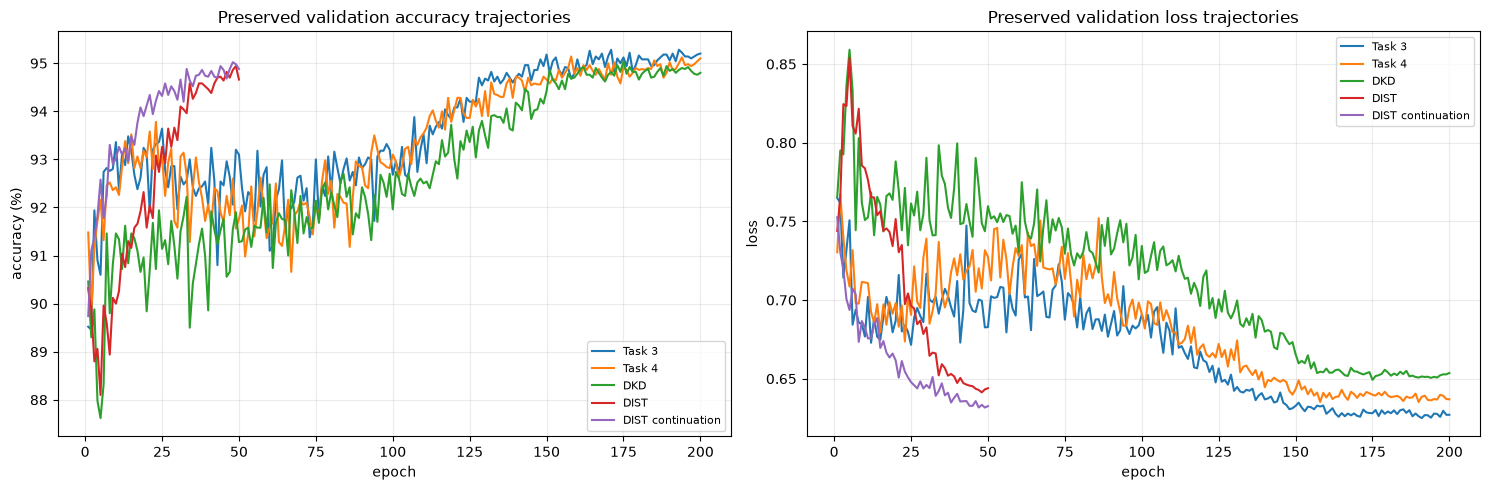

All curves loaded from preserved histories; no training executed here.


In [4]:
history_paths = {
    "Task 3": ROOT / "experiments/histories/task3_b2_default/resnet18_ternary_seed44.json",
    "Task 4": ROOT / "experiments/task4/histories/task4_b3_final_t2_lam09_rerun1/seed42.json",
    "DKD": ROOT / "experiments/task4/histories/task5_dkd_final_t2_lam09_a1_b8_r1/seed42.json",
    "DIST": ROOT / "experiments/task4/histories/task6_dist_screen_t2_lam09_i1_a1_r1/seed42.json",
    "DIST continuation": ROOT / "experiments/task4/histories/task7_dist_t1_lam05_r1/seed42.json",
}
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for name, path in history_paths.items():
    payload = load_json(path)
    hist = payload["history"]
    val = hist.get("val_acc", [])
    loss = hist.get("val_loss", [])
    if val: axes[0].plot(np.arange(1, len(val)+1), np.asarray(val)*100, label=name)
    if loss: axes[1].plot(np.arange(1, len(loss)+1), loss, label=name)
axes[0].set_title("Preserved validation accuracy trajectories")
axes[0].set_ylabel("accuracy (%)")
axes[1].set_title("Preserved validation loss trajectories")
axes[1].set_ylabel("loss")
for ax in axes:
    ax.set_xlabel("epoch"); ax.grid(alpha=.25); ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(PLOTS / "advanced_validation_curves.png", dpi=180); plt.show()
print("All curves loaded from preserved histories; no training executed here.")

[
  {
    "method": "Task 4",
    "agreement": 0.9562,
    "ce": 0.6352186723709107,
    "kd": 0.10030879554748535,
    "student_confidence": 0.8871034702301025,
    "student_correct": 0.9514,
    "student_entropy": 0.5664772953987122,
    "student_margin": 0.8645187539100647,
    "teacher_confidence": 0.8974391421318054,
    "teacher_correct": 0.9554,
    "teacher_entropy": 0.5315583398818969,
    "teacher_margin": 0.8771539717674255
  },
  {
    "method": "DKD",
    "agreement": 0.954,
    "ce": 0.6492750408172607,
    "kd": 0.5784448991179466,
    "student_confidence": 0.8810701972007752,
    "student_correct": 0.9504,
    "student_entropy": 0.5903617542266846,
    "student_margin": 0.8617911397933959,
    "teacher_confidence": 0.8974391421318054,
    "teacher_correct": 0.9554,
    "teacher_entropy": 0.5315583398818969,
    "teacher_margin": 0.8771539717674255
  },
  {
    "method": "DIST",
    "agreement": 0.953,
    "ce": 0.6432071934700012,
    "kd": 2.284693326950073,
    "stude

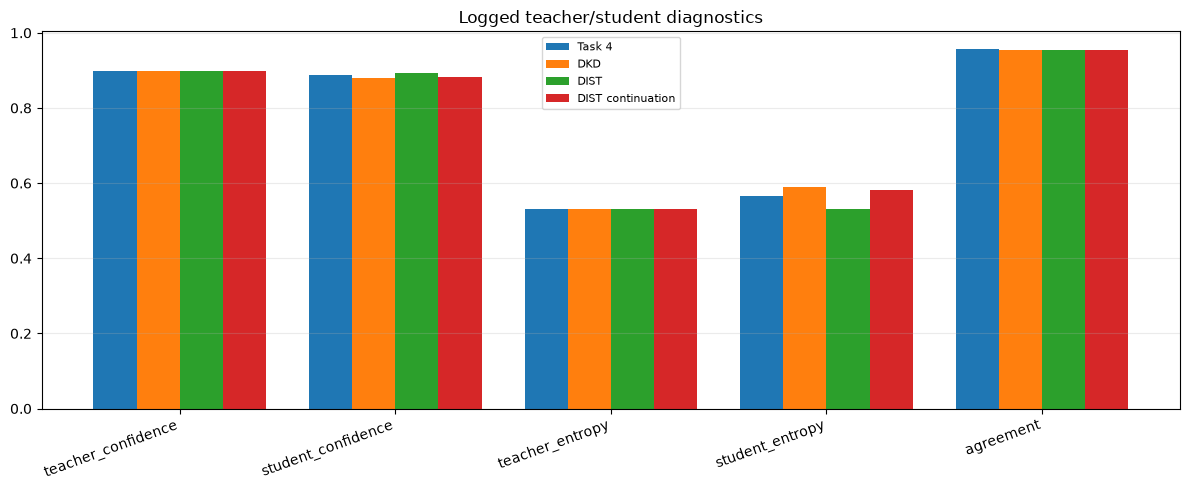

In [5]:
import csv
diagnostic_paths = {
    "Task 4": ROOT / "experiments/task4/diagnostics/task4_b3_final_t2_lam09_rerun1/seed42.json",
    "DKD": ROOT / "experiments/task4/diagnostics/task5_dkd_final_t2_lam09_a1_b8_r1/seed42.json",
    "DIST": ROOT / "experiments/task4/diagnostics/task6_dist_screen_t2_lam09_i1_a1_r1/seed42.json",
    "DIST continuation": ROOT / "experiments/task4/diagnostics/task7_dist_t1_lam05_r1/seed42.json",
}
prediction = []
for name, path in diagnostic_paths.items():
    payload = load_json(path)
    row = payload.get("validation_kd", payload.get("validation_kd_diagnostics", {}))
    prediction.append({"method": name, **row})
print(json.dumps(prediction, indent=2))
fields = sorted({key for row in prediction for key in row})
with (OUT / "prediction_diagnostics.csv").open("w", newline="") as handle:
    writer = csv.DictWriter(handle, fieldnames=fields); writer.writeheader(); writer.writerows(prediction)

fig, ax = plt.subplots(figsize=(12, 5))
metrics = ["teacher_confidence", "student_confidence", "teacher_entropy", "student_entropy", "agreement"]
x = np.arange(len(metrics)); width = .2
for i, row in enumerate(prediction):
    ax.bar(x + i*width, [row.get(metric, np.nan) for metric in metrics], width, label=row["method"])
ax.set_xticks(x + width*(len(prediction)-1)/2); ax.set_xticklabels(metrics, rotation=20, ha="right")
ax.set_title("Logged teacher/student diagnostics")
ax.legend(fontsize=8); ax.grid(axis="y", alpha=.25)
fig.tight_layout(); fig.savefig(PLOTS / "advanced_prediction_diagnostics.png", dpi=180); plt.show()

## 4. Final connected state and future continuation

In [6]:
final_state = {
    "current_best_method": STATE["final_method"],
    "current_best_validation_mean": STATE["final_validation_mean"],
    "task4_control": STATE["task4_validation"],
    "dkd": {"mean": registry["DKD"]["validation_mean"], "best": registry["DKD"].get("validation_best")},
    "dist_screen": {"mean": registry["DIST_screen"]["validation_mean"]},
    "dist_continuation": {"mean": registry["DIST_continuation"]["validation_mean"], "status": "provisional negative"},
    "test_evaluation": "LOCKED_NOT_RUN",
    "unsupported_methods": ["FitNet", "Attention Transfer", "RKD", "QFD", "QTRD", "adaptive KD", "progressive QAT"],
    "future_action": "Implement and validate one supported new method in production code before adding a new training cell.",
}
(OUT / "final_connected_state.json").write_text(json.dumps(final_state, indent=2) + "\n")
print(json.dumps(final_state, indent=2))
print("PASS: notebook is artifact-first, resumable, test-locked, and does not retrain completed experiments.")

{
  "current_best_method": "vanilla KD (Task 4 control)",
  "current_best_validation_mean": 0.9512,
  "task4_control": {
    "mean": 0.9512,
    "std": 0.00151,
    "per_seed": {
      "42": 0.9514,
      "43": 0.9496,
      "44": 0.9526
    }
  },
  "dkd": {
    "mean": 0.9488,
    "best": 0.9504
  },
  "dist_screen": {
    "mean": 0.9494
  },
  "dist_continuation": {
    "mean": 0.9502,
    "status": "provisional negative"
  },
  "test_evaluation": "LOCKED_NOT_RUN",
  "unsupported_methods": [
    "FitNet",
    "Attention Transfer",
    "RKD",
    "QFD",
    "QTRD",
    "adaptive KD",
    "progressive QAT"
  ],
  "future_action": "Implement and validate one supported new method in production code before adding a new training cell."
}
PASS: notebook is artifact-first, resumable, test-locked, and does not retrain completed experiments.
